#  SIS Epidemic Dynamics on Configuration Model Network

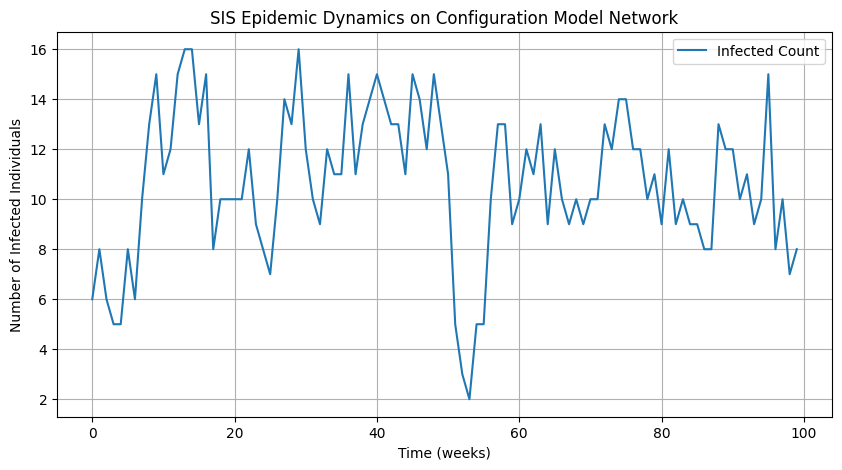

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt



# Parameters
#code is a time series pertaining to question 2c

beta = 0.3  # Transmission rate (week^-1)
alpha = 1.0  # Recovery rate (week^-1)
p = 1/4  # Probability for geometric distribution
N = 101  # Total number of nodes
vaccination_rate = 0.4  # 40% vaccination
timesteps = 100  # Number of timesteps to simulate

# Generate a geometric degree distribution

def geometric_degree_distribution(p, N):
    degrees = np.random.geometric(p, N)
    return degrees

# Create a configuration model network

def create_network(N, p):
    degrees = geometric_degree_distribution(p, N)
    G = nx.configuration_model(degrees)
    return G

# Initialize the SIS model on the network
def initialize_sis(G, vaccination_rate):
    # Vaccinate 40% of the nodes
    nodes = list(G.nodes())
    vaccinated_nodes = random.sample(nodes, int(N * vaccination_rate))
    # Status: 0 = susceptible, 1 = infected, 2 = vaccinated
    status = {node: 0 for node in nodes}
    for node in vaccinated_nodes:
        status[node] = 2  # vaccinated nodes
    # Randomly infect some nodes
    initially_infected = random.sample(nodes, int(N * 0.1))  # 10% initially infected
    for node in initially_infected:
        if status[node] == 0:  # Only infect susceptible nodes
            status[node] = 1  # infected

    return status

# SIS dynamics update
def sis_update(G, status):
    new_status = status.copy()
    for node in G.nodes():
        if status[node] == 1:  # If infected
            if random.random() < alpha:  # Recovery
                new_status[node] = 0
        elif status[node] == 0:  # If susceptible
            # Check neighbors for infection
            infected_neighbors = sum(1 for neighbor in G.neighbors(node) if status[neighbor] == 1)
            if infected_neighbors > 0 and random.random() < beta * infected_neighbors:
                new_status[node] = 1  # Become infected
    return new_status

# Main simulation
def simulate_sis(N, beta, alpha, vaccination_rate, timesteps):
    G = create_network(N, p)
    status = initialize_sis(G, vaccination_rate)

    infected_counts = []

    for t in range(timesteps):
        infected_count = sum(1 for s in status.values() if s == 1)
        infected_counts.append(infected_count)
        status = sis_update(G, status)

    return infected_counts




# Run the simulation
infected_counts = simulate_sis(N, beta, alpha, vaccination_rate, timesteps)

# Plot the results

plt.figure(figsize=(10, 5))
plt.plot(infected_counts, label='Infected Count')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.title('SIS Epidemic Dynamics on Configuration Model Network')

plt.legend()
plt.grid()
plt.show()



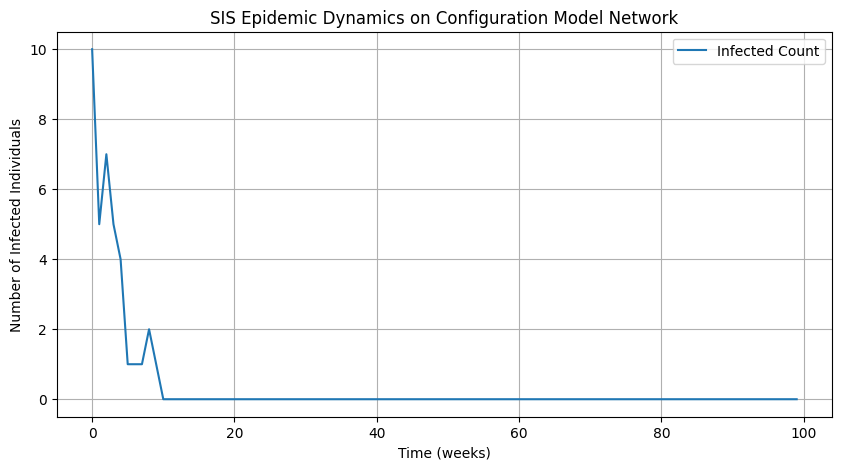

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt



# Parameters
#code is a time series pertaining to question 2c

beta = 0.3  # Transmission rate (week^-1)
alpha = 1   # Recovery rate (week^-1)
#alpha = .01
p = 1/4  # Probability for geometric distribution
N = 101  # Total number of nodes
vaccination_rate = 0.4  # 40% vaccination
timesteps = 100  # Number of timesteps to simulate
rho_values = .4


# Generate a geometric degree distribution

def geometric_degree_distribution(p, N):
    degrees = np.random.geometric(p, N)
    return degrees

# Create a configuration model network

def create_network(N, p):
    degrees = geometric_degree_distribution(p, N)
    G = nx.configuration_model(degrees)
    return G

# Initialize the SIS model on the network
def initialize_sis(G, vaccination_rate):
    # Vaccinate 40% of the nodes
    nodes = list(G.nodes())
    vaccinated_nodes = random.sample(nodes, int(N * vaccination_rate))
    # Status: 0 = susceptible, 1 = infected, 2 = vaccinated
    status = {node: 0 for node in nodes}
    for node in vaccinated_nodes:
        status[node] = 2  # vaccinated nodes
    # Randomly infect some nodes
    initially_infected = random.sample(nodes, int(N * 0.1))  # 10% initially infected
    for node in initially_infected:
        if status[node] == 0:  # Only infect susceptible nodes
            status[node] = 1  # infected

    return status

# SIS dynamics update
def sis_update(G, status):
    new_status = status.copy()
    for node in G.nodes():
        if status[node] == 1:  # If infected
            if random.random() < alpha:  # Recovery
                new_status[node] = 0
        elif status[node] == 0:  # If susceptible
            # Check neighbors for infection
            infected_neighbors = sum(1 for neighbor in G.neighbors(node) if status[neighbor] == 1)
            if infected_neighbors > 0 and random.random() < (1-rho_values)*beta * infected_neighbors:
                new_status[node] = 1  # Become infected
    return new_status

# Main simulation
def simulate_sis(N, beta, alpha, vaccination_rate, timesteps):
    G = create_network(N, p)
    status = initialize_sis(G, vaccination_rate)

    infected_counts = []

    for t in range(timesteps):
        infected_count = sum(1 for s in status.values() if s == 1)
        infected_counts.append(infected_count)
        status = sis_update(G, status)

    return infected_counts




# Run the simulation
infected_counts = simulate_sis(N, beta, alpha, vaccination_rate, timesteps)

# Plot the results

plt.figure(figsize=(10, 5))
plt.plot(infected_counts, label='Infected Count')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.title('SIS Epidemic Dynamics on Configuration Model Network')

plt.legend()
plt.grid()
plt.show()



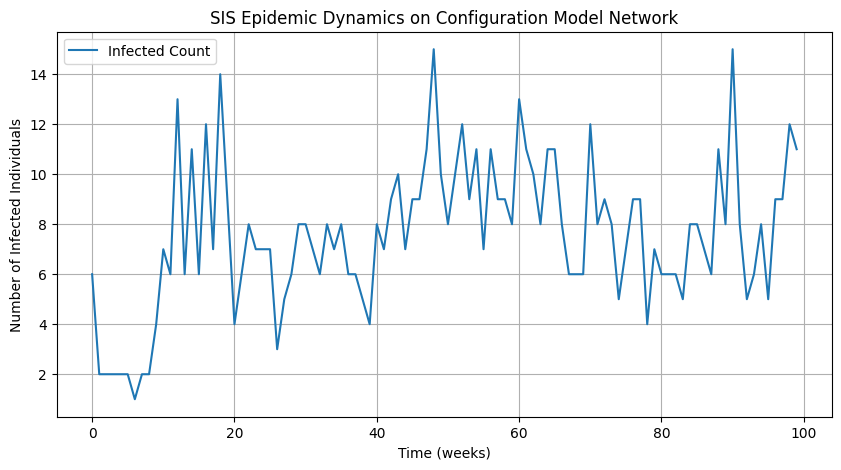

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt



# Parameters
#code is a time series pertaining to question 2c

beta = 0.3  # Transmission rate (week^-1)
alpha = 1   # Recovery rate (week^-1)
#alpha = .01
p = 1/4  # Probability for geometric distribution
N = 101  # Total number of nodes
vaccination_rate = 0.4  # 40% vaccination
timesteps = 100  # Number of timesteps to simulate
rho_values = .1


# Generate a geometric degree distribution

def geometric_degree_distribution(p, N):
    degrees = np.random.geometric(p, N)
    return degrees

# Create a configuration model network

def create_network(N, p):
    degrees = geometric_degree_distribution(p, N)
    G = nx.configuration_model(degrees)
    return G

# Initialize the SIS model on the network
def initialize_sis(G, vaccination_rate):
    # Vaccinate 40% of the nodes
    nodes = list(G.nodes())
    vaccinated_nodes = random.sample(nodes, int(N * vaccination_rate))
    # Status: 0 = susceptible, 1 = infected, 2 = vaccinated
    status = {node: 0 for node in nodes}
    for node in vaccinated_nodes:
        status[node] = 2  # vaccinated nodes
    # Randomly infect some nodes
    initially_infected = random.sample(nodes, int(N * 0.1))  # 10% initially infected
    for node in initially_infected:
        if status[node] == 0:  # Only infect susceptible nodes
            status[node] = 1  # infected

    return status

# SIS dynamics update
def sis_update(G, status):
    new_status = status.copy()
    for node in G.nodes():
        if status[node] == 1:  # If infected
            if random.random() < alpha:  # Recovery
                new_status[node] = 0
        elif status[node] == 0:  # If susceptible
            # Check neighbors for infection
            infected_neighbors = sum(1 for neighbor in G.neighbors(node) if status[neighbor] == 1)
            if infected_neighbors > 0 and random.random() < (1-rho_values)*beta * infected_neighbors:
                new_status[node] = 1  # Become infected
    return new_status

# Main simulation
def simulate_sis(N, beta, alpha, vaccination_rate, timesteps):
    G = create_network(N, p)
    status = initialize_sis(G, vaccination_rate)

    infected_counts = []

    for t in range(timesteps):
        infected_count = sum(1 for s in status.values() if s == 1)
        infected_counts.append(infected_count)
        status = sis_update(G, status)

    return infected_counts




# Run the simulation
infected_counts = simulate_sis(N, beta, alpha, vaccination_rate, timesteps)

# Plot the results

plt.figure(figsize=(10, 5))
plt.plot(infected_counts, label='Infected Count')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.title('SIS Epidemic Dynamics on Configuration Model Network')

plt.legend()
plt.grid()
plt.show()



# 2c code

4.28


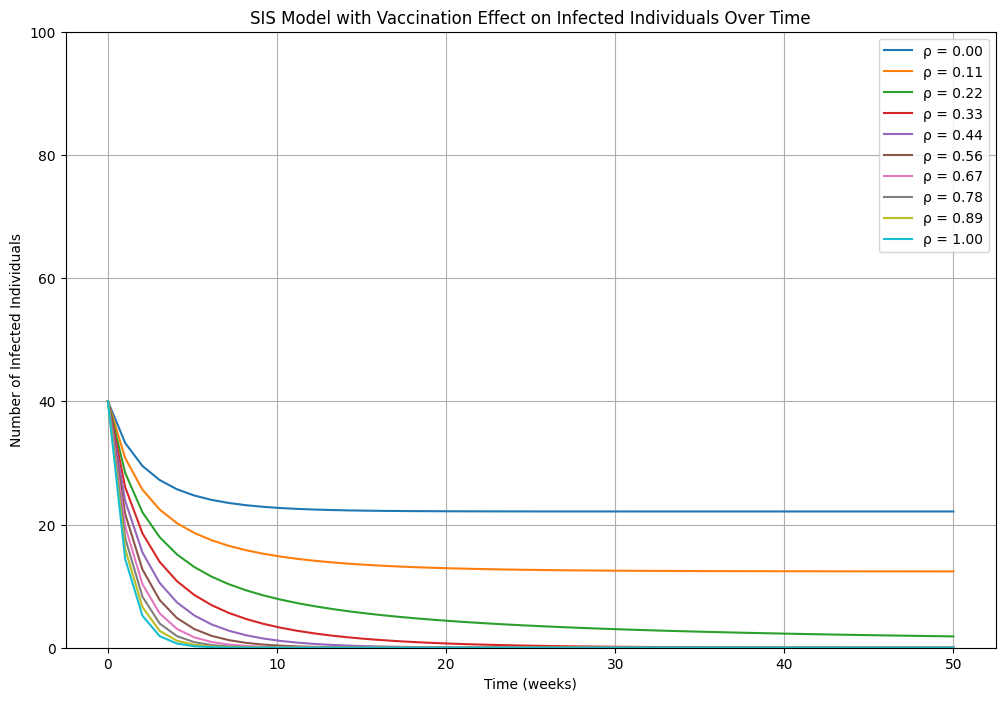

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
beta = 0.3  # transmission rate (week^-1)
alpha = 1.0  # recovery rate (week^-1)
p = 0.25  # probability in geometric distribution
vaccination_rate = 0.4  # 40% of the population is vaccinated
rho_values = np.linspace(0, 1, 10)  # varying rho from 0 to 1

# Function to generate the degree distribution
def geometric_degree_distribution(p, max_k=100):
    return np.array([(1 - p) ** k * p for k in range(max_k)])

# Number of individuals
N = 100
max_k = 100
degrees = np.random.choice(range(max_k), size=N, p=geometric_degree_distribution(p, max_k))
avg_degree = np.mean(degrees)

print(avg_degree)

# SIS model equations
def sis_model(y, t, beta, alpha, rho, vaccinated_count):
    S, I = y

    # Calculate the infection rate
    infection_rate = (1 - rho) * beta * np.mean(degrees) * (I/N)
    # Calculate the recovery rate
    recovery_rate = alpha

    #change in Susceptible and Infected nodes with respect to time using ODE
    dSdt = -infection_rate * S + recovery_rate * I
    dIdt = infection_rate * S - recovery_rate * I

    return [dSdt, dIdt]

# Run the simulation for different values of rho
#time_points = np.linspace(0, 50, 500)  # time from 0 to 50 weeks

time_points = np.linspace(0, 50, 50)  # time from 0 to 50 weeks
initial_conditions = [N * (1 - vaccination_rate), N * vaccination_rate]  # S0, I0

results = []

for rho in rho_values:
    # Initial conditions for the vaccinated population
    vaccinated_count = int(vaccination_rate * N)
    unvaccinated_count = N - vaccinated_count

    # Run the integration
    result = odeint(sis_model, initial_conditions, time_points, args=(beta, alpha, rho, vaccinated_count))
    results.append(result)

# Plot the results
plt.figure(figsize=(12, 8))
for i, rho in enumerate(rho_values):
    S, I = results[i][:, 0], results[i][:, 1]
    plt.plot(time_points, I, label=f'ρ = {rho:.2f}')

plt.title('SIS Model with Vaccination Effect on Infected Individuals Over Time')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.ylim(0, N)
plt.grid()
plt.show()


# Wondered if rho=.4 may be an important value to completely eradicate an outbreak with .4 prevalence

4.05


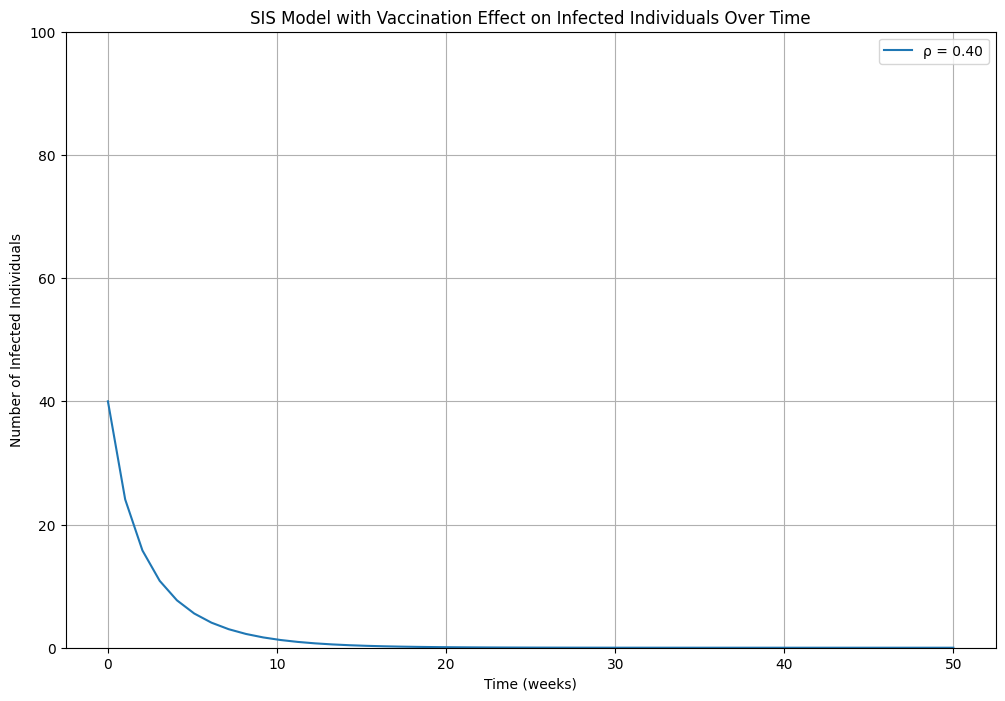

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
beta = 0.3  # transmission rate (week^-1)
alpha = 1.0  # recovery rate (week^-1)
p = 0.25  # probability in geometric distribution
vaccination_rate = 0.4  # 40% of the population is vaccinated
#rho_values = np.linspace(0, 1, 10)  # varying rho from 0 to 1

rho_values = .4

# Function to generate the degree distribution
def geometric_degree_distribution(p, max_k=100):
    return np.array([(1 - p) ** k * p for k in range(max_k)])

# Number of individuals
N = 100
max_k = 100
degrees = np.random.choice(range(max_k), size=N, p=geometric_degree_distribution(p, max_k))
avg_degree = np.mean(degrees)

print(avg_degree)

# SIS model equations
def sis_model(y, t, beta, alpha, rho, vaccinated_count):
    S, I = y

    # Calculate the infection rate
    infection_rate = (1 - rho) * beta * np.mean(degrees) * (I/N)
    # Calculate the recovery rate
    recovery_rate = alpha

    #change in Susceptible and Infected nodes with respect to time using ODE
    dSdt = -infection_rate * S + recovery_rate * I
    dIdt = infection_rate * S - recovery_rate * I

    return [dSdt, dIdt]

# Run the simulation for different values of rho
time_points = np.linspace(0, 50, 500)  # time from 0 to 50 weeks

time_points = np.linspace(0, 50, 50)  # time from 0 to 50 weeks
initial_conditions = [N * (1 - vaccination_rate), N * vaccination_rate]  # S0, I0

results = []

#for rho in rho_values:
    # Initial conditions for the vaccinated population
vaccinated_count = int(vaccination_rate * N)
unvaccinated_count = N - vaccinated_count

    # Run the integration
result = odeint(sis_model, initial_conditions, time_points, args=(beta, alpha, rho_values, vaccinated_count))
results.append(result)

# Plot the results
plt.figure(figsize=(12, 8))
#for i, rho in enumerate(rho_values):
S, I = results[0][:, 0], results[0][:, 1]
plt.plot(time_points, I, label=f'ρ = {rho_values:.2f}')

plt.title('SIS Model with Vaccination Effect on Infected Individuals Over Time')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.ylim(0, N)
plt.grid()
plt.show()


# 2d Code

3.48


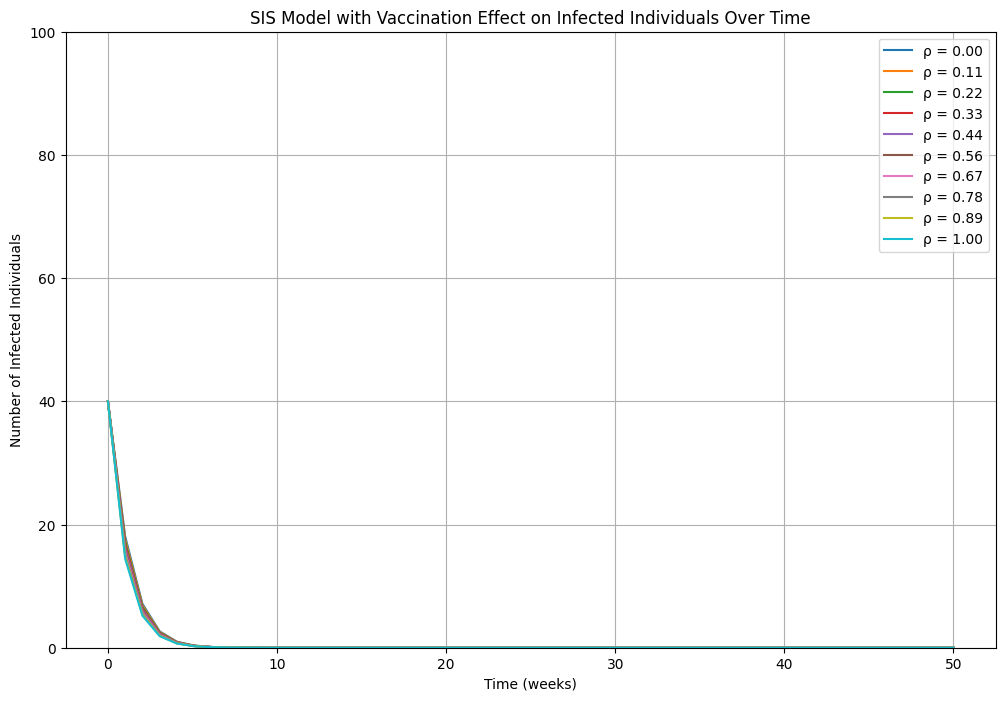

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
beta = 0.3  # transmission rate (week^-1)
alpha = 1.0  # recovery rate (week^-1)
p = 0.25  # probability in geometric distribution
vaccination_rate = 0.4  # 40% of the population is vaccinated
rho_values = np.linspace(0, 1, 10)  # varying rho from 0 to 1

# Function to generate the degree distribution
def geometric_degree_distribution(p, max_k=100):
    return np.array([(1 - p) ** k * p for k in range(max_k)])

# Number of individuals
N = 100
max_k = 100
degrees = np.random.choice(range(max_k), size=N, p=geometric_degree_distribution(p, max_k))
avg_degree = np.mean(degrees)

print(avg_degree)

# SIS model equations
def sis_model(y, t, beta, alpha, rho, vaccinated_count):
    S, I = y

    # # Calculate the infection rate
    # infection_rate = (1 - rho) * beta * np.mean(degrees) * (I/N)
    # # Calculate the recovery rate
    # recovery_rate = alpha

    # #change in Susceptible and Infected nodes with respect to time using ODE
    # dSdt = -infection_rate * S + recovery_rate * I
    # dIdt = infection_rate * S - recovery_rate * I




        # Calculate the degree of nodes
    degrees = np.array([d for n, d in G.degree()])

    # Vaccination: top 40% of nodes with highest degree
    vaccinated_nodes = np.argsort(degrees)[-int(N * vaccination_rate):]

    # Calculate infection probability θ
    theta = np.sum(I / N)  # fraction of infected in the population

    # Update infection and recovery rates
    infection_rate = (1 - rho) * beta * np.mean(degrees[vaccinated_nodes]) * theta
    recovery_rate = alpha

    dSdt = -infection_rate * S * theta
    dIdt = infection_rate * S * theta - recovery_rate * I

    return [dSdt, dIdt]

# Run the simulation for different values of rho
#time_points = np.linspace(0, 50, 500)  # time from 0 to 50 weeks

time_points = np.linspace(0, 50, 50)  # time from 0 to 50 weeks
initial_conditions = [N * (1 - vaccination_rate), N * vaccination_rate]  # S0, I0

results = []

for rho in rho_values:
    # Initial conditions for the vaccinated population
    vaccinated_count = int(vaccination_rate * N)
    unvaccinated_count = N - vaccinated_count

    # Run the integration
    result = odeint(sis_model, initial_conditions, time_points, args=(beta, alpha, rho, vaccinated_count))
    results.append(result)

# Plot the results
plt.figure(figsize=(12, 8))
for i, rho in enumerate(rho_values):
    S, I = results[i][:, 0], results[i][:, 1]
    plt.plot(time_points, I, label=f'ρ = {rho:.2f}')

plt.title('SIS Model with Vaccination Effect on Infected Individuals Over Time')
plt.xlabel('Time (weeks)')
plt.ylabel('Number of Infected Individuals')
plt.legend()
plt.ylim(0, N)
plt.grid()
plt.show()



# More 2d debugs

NetworkXError: Invalid degree sequence: sum of degrees must be even, not odd

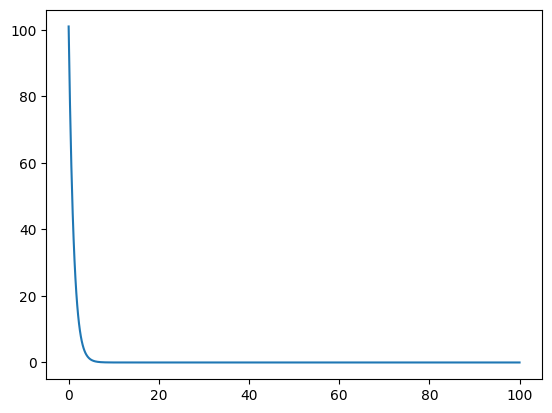

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
beta = 0.3  # transmission rate (week^-1)
alpha = 1.0  # recovery rate (week^-1)
p = 1/4  # parameter for geometric distribution
N = 1001  # total population size
vaccination_rate = 0.4  # 40% vaccination
max_degree = int(1 / p)  # maximum degree in geometric distribution
rho_values = np.linspace(.22, 1, 9)  # values of rho to test

# Create geometric degree distribution
def geometric_degree_distribution(N, p):
    degrees = np.random.geometric(p, N) - 1  # zero-indexed
    return degrees

# Generate configuration model network
def generate_network(N, p):
    degrees = geometric_degree_distribution(N, p)
    G = nx.configuration_model(degrees)
    return G

# SIS model dynamics
def sis_dynamics(y, t, beta, alpha, G, rho):
    S, I = y
    N = S + I

    # Calculate the degree of nodes
    degrees = np.array([d for n, d in G.degree()])

    # Vaccination: top 40% of nodes with highest degree
    vaccinated_nodes = np.argsort(degrees)[-int(N * vaccination_rate):]

    # Calculate infection probability θ
    theta = np.sum(I / N)  # fraction of infected in the population

    # Update infection and recovery rates
    infection_rate = (1 - rho) * beta * np.mean(degrees[vaccinated_nodes]) * theta
    recovery_rate = alpha

    dSdt = -infection_rate * S * theta
    dIdt = infection_rate * S * theta - recovery_rate * I

    return [dSdt, dIdt]


# Simulation and plotting
def simulate_sis(rho):
    G = generate_network(N, p)
    S0 = int(N * 0.9)  # 90% susceptible
    I0 = N - S0  # 10% infected
    y0 = [S0, I0]
    t = np.linspace(0, 100, 1000)  # time from 0 to 100 weeks

    sol = odeint(sis_dynamics, y0, t, args=(beta, alpha, G, rho))
    return t, sol

# Main loop for varying rho and plotting results
for rho in rho_values:
    t, sol = simulate_sis(rho)
    S, I = sol.T
    plt.plot(t, I, label=f'ρ={rho:.2f}')

plt.title('SIS Model with Vaccination Effect')
plt.xlabel('Time (weeks)')
plt.ylabel('Infected Individuals')
plt.legend()
plt.ylim(0, max([max(sol[:, 1]) for sol in [simulate_sis(rho) for rho in rho_values]]) * 1.1)
plt.grid()
plt.show()

# Using the integrator of your choice, test how strong ρ needs to be to eradicate an
# outbreak with the following parameters: transmission rate β = 0.3 (week−1
# ) and
# recovery rate α = 1 (week−1
# ) in a population with a geometric degree distribution
# pk = p(1 − p)
# k with p = 1/4. Assume that a random 40% of the population gets
# vaccinated.



#Some code for 3

Executing: /tmp/apt-key-gpghome.TO2AGugmT3/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
gpg: key 612DEFB798507F25: "Tiago de Paula Peixoto <tiago@skewed.de>" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
nx: 3.4.2
graph-tool: 2.79 (commit 7601999f, Sat Oct 26 13:33:56 2024 +0200)
analyses
----------
average_degree: 5.129032258064516
degree_assortativity: -0.043594028215312566
degree_std_dev: 2.9319368857779358
diameter: 8
edge_properties: []
edge_reciprocity: 1.0
global_clustering: 0.3087757313109426
hashimoto_radius: 5.9934866396101665
is_bipartite: False
is_directed: False
knn_proj_1: 3.4431036001070403
knn_proj_2: 1.7587075895393856
largest_component_fraction: 1.0
mixing_time: 24.797367925740065
num_edges: 159
num_vertices: 62
transition_gap: 0.9604754462425675
vertex_properties: [['label', 'string'], ['_pos', 'vector<double>']]


bibtex
----------
['@article{lusseau_bottlenose_2003,\n  doi          = {10.1007/s00265-003-0651-y},\

AttributeError: 'Graph' object has no attribute 'nodes'

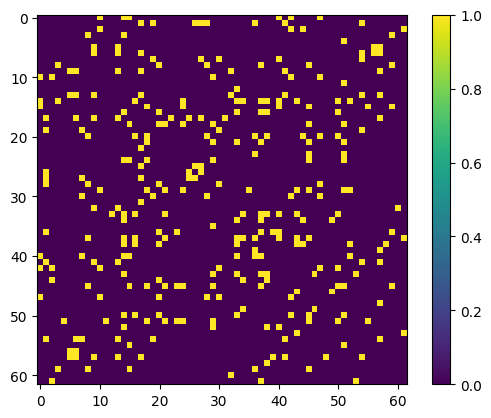

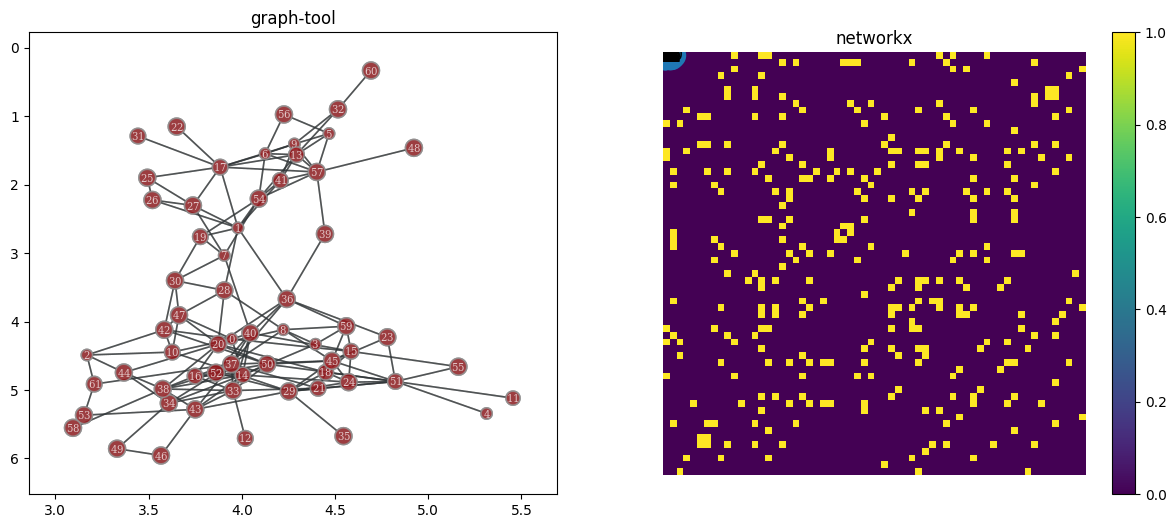

In [ ]:
#Example of applying code from consensus model to whatever is used in problem 3

#code Jonathan originally supplied, used to analyze question 3
#@title setting 1
!echo "deb http://downloads.skewed.de/apt jammy main" >> /etc/apt/sources.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
!apt-get update &> /dev/null
!apt-get install python3-graph-tool python3-matplotlib python3-cairo &> /dev/null

#@title setting 2
# Colab uses a Python install that deviates from the system's! Bad collab! We need some workarounds.
!apt purge python3-cairo &> /dev/null
!apt install libcairo2-dev pkg-config python3-dev &> /dev/null
!pip install --force-reinstall pycairo &> /dev/null
!pip install zstandard &> /dev/null

#@title import libraries

import networkx as nx
import numpy as np
import graph_tool.all as gt
from collections import Counter
import matplotlib.pyplot as plt
import json
import pandas as pd
import csv

print(f"nx: {nx.__version__}")
print(f"graph-tool: {gt.__version__}")

#@title helper functions
def print_summary(name, subname=None):
  for k,v in gt.collection.ns_info[name].items():
    print(k, end="\n----------\n")
    if subname is not None and k == 'analyses':
      v = gt.collection.ns_info[name]['analyses'][subname]
      for ka, va in v.items():
        print(f"{ka}: {va}")
      continue
    if isinstance(v, dict):
      for ka, va in v.items():
        print(f"{ka}: {va}")
    else:
      print(v)
    print("\n")


def prop_to_size_custom(values, min_bound=5, max_bound=15):
    """
    Normalizes a list of floats to be within a specified range [min_bound, max_bound].

    Parameters:
    values (list of float): The list of values to be normalized.
    min_bound (float): The minimum bound of the normalized range (default is 5).
    max_bound (float): The maximum bound of the normalized range (default is 15).

    Returns:
    list of float: The list with values normalized to the specified range.
    """
    min_val = min(values)
    max_val = max(values)
    # Prevent division by zero if all values are the same
    if min_val == max_val:
        return [min_bound] * len(values)

    return [
        min_bound + (value - min_val) * (max_bound - min_bound) / (max_val - min_val)
        for value in values
    ]

print_summary("dolphins")

g = gt.collection.ns["dolphins"]

A = gt.adjacency(g)

plt.imshow(A.todense()); # here's what the adj mat looks like
plt.colorbar()


Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph


fig, ax = plt.subplots(1,2, figsize=(15,6))

a = gt.graph_draw(g, pos=gt.fruchterman_reingold_layout(g), vertex_text=g.vertex_index, mplfig=ax[0])
a.fit_view(yflip=True)
ax[0].set_title("graph-tool")

nx.draw(Gnx, pos=nx.fruchterman_reingold_layout(Gnx), with_labels=True, ax=ax[1]);
ax[1].set_title("networkx");



###########################################################################

plt.imshow(A.todense()); # here's what the adj mat looks like
plt.colorbar()

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        #G = create_network(n_nodes, edge_prob)
        G = gt.collection.ns["dolphins"]
        A = gt.adjacency(g)
        Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph
        initial_states = initialize_states(Gnx, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)


ee, x = gt.eigenvector(g)

gt.graph_draw(
    g,
    pos=gt.fruchterman_reingold_layout(g),
    vertex_text=g.vertex_index,
    vertex_fill_color=x,
    vertex_size=gt.prop_to_size(x, mi=5, ma=30),
    vcmap=plt.cm.viridis
    );


fig, ax = plt.subplots(figsize=(10,8))
pos = nx.fruchterman_reingold_layout(Gnx)
eigen_vals = list(nx.eigenvector_centrality(Gnx).values())
node_attr = {
    "node_size": prop_to_size_custom(eigen_vals, 100, 400), # had to write a helper function
    'edgecolors': 'grey',
    "node_color": eigen_vals
  }
nx.draw_networkx_nodes(Gnx, pos=pos, ax=ax, cmap=plt.cm.viridis, **node_attr)
nx.draw_networkx_edges(Gnx, pos=pos, ax=ax)
nx.draw_networkx_labels(Gnx, pos=pos);


g = gt.collection.ns["dolphins"]
fig, ax = plt.subplots(1,3, figsize=(15,5))
titles = ["who do you get on with in the dolphins."]
for i in range(3):
  u = gt.GraphView(g, efilt=g.ep.layer.a == (i+1))
  state = gt.minimize_blockmodel_dl(u)
  a = state.draw(mplfig=ax[i])
  a.fit_view(yflip=True)
  ax[i].set_title(titles[i])


  print_summary("ego_social", "facebook_combined")

  g = gt.collection.ns["ego_social/facebook_combined"]

  gt.graph_draw(g, pos=g.vp._pos);


  print_summary("advogato")


  g = gt.collection.ns["advogato"]

  gt.graph_draw(g, pos=g.vp._pos); # nodes positionned according to metadata

  u = gt.extract_largest_component(g, prune=True) # https://graph-tool.skewed.de/static/doc/autosummary/graph_tool.topology.extract_largest_component.html

  gt.graph_draw(u);

  vb, eb = gt.betweenness(u)
gt.graph_draw(u, pos = gt.sfdp_layout(u), vertex_fill_color=gt.prop_to_size(vb, 0, 1, power=.1),
              vertex_size=gt.prop_to_size(vb, 3, 12, power=.2), vorder=vb);

kcore = gt.kcore_decomposition(u)

count_kcore = Counter(kcore)
plt.bar(x=count_kcore.keys(), height=count_kcore.values())
plt.xlabel('kcore')
plt.ylabel('count');


chosen_kcore = [(k > 3) and (k < 29) for k in kcore]

uk = gt.GraphView(u, vfilt=chosen_kcore)

gt.graph_draw(
    uk,
    pos=gt.sfdp_layout(uk),
  )



# Start of 4

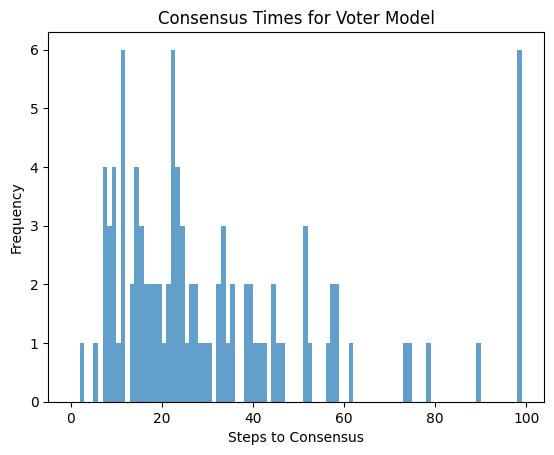

mean 31.97
median 23.5
mode 99
stdev 24.560975451954572
variance 603.2415151515152


In [ ]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        G = create_network(n_nodes, edge_prob)
        initial_states = initialize_states(G, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)



import statistics

mean = statistics.mean(consensus_times)
median = statistics.median(consensus_times)
mode = statistics.mode(consensus_times)
stdev = statistics.stdev(consensus_times)
variance = statistics.variance(consensus_times)

print('mean',mean)
print('median',median)
print('mode',mode)
print('stdev',stdev)
print('variance',variance)


Executing: /tmp/apt-key-gpghome.dDRxfBUREr/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
gpg: key 612DEFB798507F25: "Tiago de Paula Peixoto <tiago@skewed.de>" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
nx: 3.4.2
graph-tool: 2.79 (commit 7601999f, Sat Oct 26 13:33:56 2024 +0200)


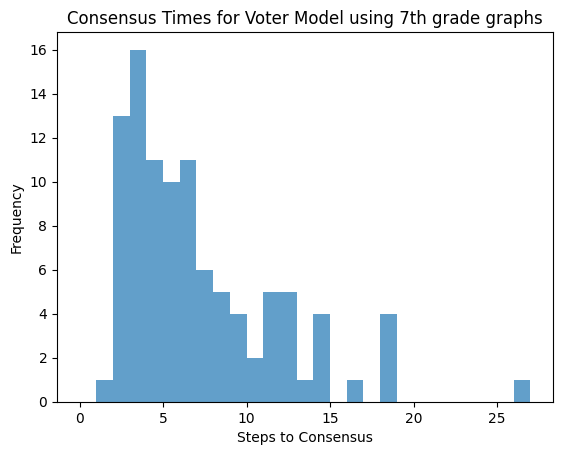

In [ ]:
#Example of applying code from consensus model to whatever is used in problem 3
#this would be how to answer 4a but using whatever graph network you choose instead of 7th graders

#@title setting 1
!echo "deb http://downloads.skewed.de/apt jammy main" >> /etc/apt/sources.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
!apt-get update &> /dev/null
!apt-get install python3-graph-tool python3-matplotlib python3-cairo &> /dev/null

#@title setting 2
# Colab uses a Python install that deviates from the system's! Bad collab! We need some workarounds.
!apt purge python3-cairo &> /dev/null
!apt install libcairo2-dev pkg-config python3-dev &> /dev/null
!pip install --force-reinstall pycairo &> /dev/null
!pip install zstandard &> /dev/null

#@title import libraries

import networkx as nx
import numpy as np
import graph_tool.all as gt
from collections import Counter
import matplotlib.pyplot as plt
import json
import pandas as pd
import csv

print(f"nx: {nx.__version__}")
print(f"graph-tool: {gt.__version__}")

#@title helper functions
def print_summary(name, subname=None):
  for k,v in gt.collection.ns_info[name].items():
    print(k, end="\n----------\n")
    if subname is not None and k == 'analyses':
      v = gt.collection.ns_info[name]['analyses'][subname]
      for ka, va in v.items():
        print(f"{ka}: {va}")
      continue
    if isinstance(v, dict):
      for ka, va in v.items():
        print(f"{ka}: {va}")
    else:
      print(v)
    print("\n")


def prop_to_size_custom(values, min_bound=5, max_bound=15):
    """
    Normalizes a list of floats to be within a specified range [min_bound, max_bound].

    Parameters:
    values (list of float): The list of values to be normalized.
    min_bound (float): The minimum bound of the normalized range (default is 5).
    max_bound (float): The maximum bound of the normalized range (default is 15).

    Returns:
    list of float: The list with values normalized to the specified range.
    """
    min_val = min(values)
    max_val = max(values)
    # Prevent division by zero if all values are the same
    if min_val == max_val:
        return [min_bound] * len(values)

    return [
        min_bound + (value - min_val) * (max_bound - min_bound) / (max_val - min_val)
        for value in values
    ]



###########################################################################

#plt.imshow(A.todense()); # here's what the adj mat looks like
#plt.colorbar()

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        #G = create_network(n_nodes, edge_prob)
        G = gt.collection.ns["7th_graders"]
        A = gt.adjacency(g)
        G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
        #Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph
        initial_states = initialize_states(G, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model using 7th grade graphs')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)


In [ ]:
#Example of applying code from consensus model to whatever is used in problem 3
#this would be how to answer 4a but using whatever graph network you choose instead of 7th graders

#@title setting 1
!echo "deb http://downloads.skewed.de/apt jammy main" >> /etc/apt/sources.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
!apt-get update &> /dev/null
!apt-get install python3-graph-tool python3-matplotlib python3-cairo &> /dev/null

#@title setting 2
# Colab uses a Python install that deviates from the system's! Bad collab! We need some workarounds.
!apt purge python3-cairo &> /dev/null
!apt install libcairo2-dev pkg-config python3-dev &> /dev/null
!pip install --force-reinstall pycairo &> /dev/null
!pip install zstandard &> /dev/null

#@title import libraries

import networkx as nx
import numpy as np
import graph_tool.all as gt
from collections import Counter
import matplotlib.pyplot as plt
import json
import pandas as pd
import csv

print(f"nx: {nx.__version__}")
print(f"graph-tool: {gt.__version__}")

#@title helper functions
def print_summary(name, subname=None):
  for k,v in gt.collection.ns_info[name].items():
    print(k, end="\n----------\n")
    if subname is not None and k == 'analyses':
      v = gt.collection.ns_info[name]['analyses'][subname]
      for ka, va in v.items():
        print(f"{ka}: {va}")
      continue
    if isinstance(v, dict):
      for ka, va in v.items():
        print(f"{ka}: {va}")
    else:
      print(v)
    print("\n")


def prop_to_size_custom(values, min_bound=5, max_bound=15):
    """
    Normalizes a list of floats to be within a specified range [min_bound, max_bound].

    Parameters:
    values (list of float): The list of values to be normalized.
    min_bound (float): The minimum bound of the normalized range (default is 5).
    max_bound (float): The maximum bound of the normalized range (default is 15).

    Returns:
    list of float: The list with values normalized to the specified range.
    """
    min_val = min(values)
    max_val = max(values)
    # Prevent division by zero if all values are the same
    if min_val == max_val:
        return [min_bound] * len(values)

    return [
        min_bound + (value - min_val) * (max_bound - min_bound) / (max_val - min_val)
        for value in values
    ]



###########################################################################

#plt.imshow(A.todense()); # here's what the adj mat looks like
#plt.colorbar()

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        #G = create_network(n_nodes, edge_prob)
        G = gt.collection.ns["dolphins"]
        A = gt.adjacency(g)
        G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
        #Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph
        initial_states = initialize_states(G, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model using Dolphin Graphs')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)


Executing: /tmp/apt-key-gpghome.miWmhCpn37/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
gpg: key 612DEFB798507F25: public key "Tiago de Paula Peixoto <tiago@skewed.de>" imported
gpg: Total number processed: 1
gpg:               imported: 1
nx: 3.4.2
graph-tool: 2.79 (commit 7601999f, Sat Oct 26 13:33:56 2024 +0200)


NameError: name 'g' is not defined

Executing: /tmp/apt-key-gpghome.W2ue8piGra/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
gpg: key 612DEFB798507F25: "Tiago de Paula Peixoto <tiago@skewed.de>" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
nx: 3.4.2
graph-tool: 2.79 (commit 7601999f, Sat Oct 26 13:33:56 2024 +0200)


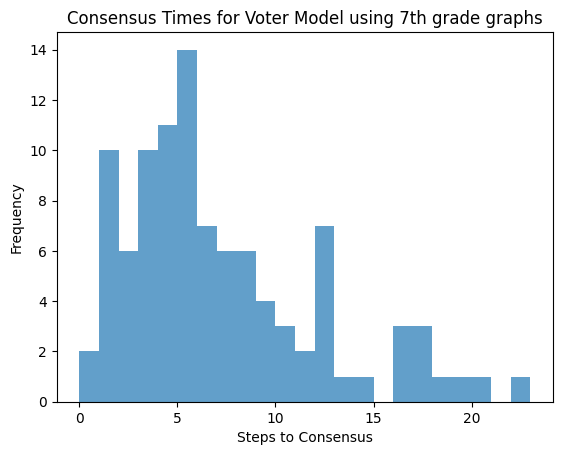

mean 6.76
median 5.0
mode 5
stdev 5.023419898311057
variance 25.234747474747476


In [ ]:
#Example of applying code from consensus model to whatever is used in problem 3
#this would be how to answer 4a but using whatever graph network you choose instead of 7th graders

#@title setting 1
!echo "deb http://downloads.skewed.de/apt jammy main" >> /etc/apt/sources.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
!apt-get update &> /dev/null
!apt-get install python3-graph-tool python3-matplotlib python3-cairo &> /dev/null

#@title setting 2
# Colab uses a Python install that deviates from the system's! Bad collab! We need some workarounds.
!apt purge python3-cairo &> /dev/null
!apt install libcairo2-dev pkg-config python3-dev &> /dev/null
!pip install --force-reinstall pycairo &> /dev/null
!pip install zstandard &> /dev/null

#@title import libraries

import networkx as nx
import numpy as np
import graph_tool.all as gt
from collections import Counter
import matplotlib.pyplot as plt
import json
import pandas as pd
import csv

print(f"nx: {nx.__version__}")
print(f"graph-tool: {gt.__version__}")

#@title helper functions
def print_summary(name, subname=None):
  for k,v in gt.collection.ns_info[name].items():
    print(k, end="\n----------\n")
    if subname is not None and k == 'analyses':
      v = gt.collection.ns_info[name]['analyses'][subname]
      for ka, va in v.items():
        print(f"{ka}: {va}")
      continue
    if isinstance(v, dict):
      for ka, va in v.items():
        print(f"{ka}: {va}")
    else:
      print(v)
    print("\n")


def prop_to_size_custom(values, min_bound=5, max_bound=15):
    """
    Normalizes a list of floats to be within a specified range [min_bound, max_bound].

    Parameters:
    values (list of float): The list of values to be normalized.
    min_bound (float): The minimum bound of the normalized range (default is 5).
    max_bound (float): The maximum bound of the normalized range (default is 15).

    Returns:
    list of float: The list with values normalized to the specified range.
    """
    min_val = min(values)
    max_val = max(values)
    # Prevent division by zero if all values are the same
    if min_val == max_val:
        return [min_bound] * len(values)

    return [
        min_bound + (value - min_val) * (max_bound - min_bound) / (max_val - min_val)
        for value in values
    ]



###########################################################################

#plt.imshow(A.todense()); # here's what the adj mat looks like
#plt.colorbar()

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        #G = create_network(n_nodes, edge_prob)
        G = gt.collection.ns["7th_graders"]
        A = gt.adjacency(G)
        G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
        #Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph
        initial_states = initialize_states(G, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model using 7th grade graphs')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)


import statistics

mean = statistics.mean(consensus_times)
median = statistics.median(consensus_times)
mode = statistics.mode(consensus_times)
stdev = statistics.stdev(consensus_times)
variance = statistics.variance(consensus_times)

print('mean',mean)
print('median',median)
print('mode',mode)
print('stdev',stdev)
print('variance',variance)


Executing: /tmp/apt-key-gpghome.XNF6c51vKX/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
gpg: key 612DEFB798507F25: "Tiago de Paula Peixoto <tiago@skewed.de>" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
nx: 3.4.2
graph-tool: 2.79 (commit 7601999f, Sat Oct 26 13:33:56 2024 +0200)


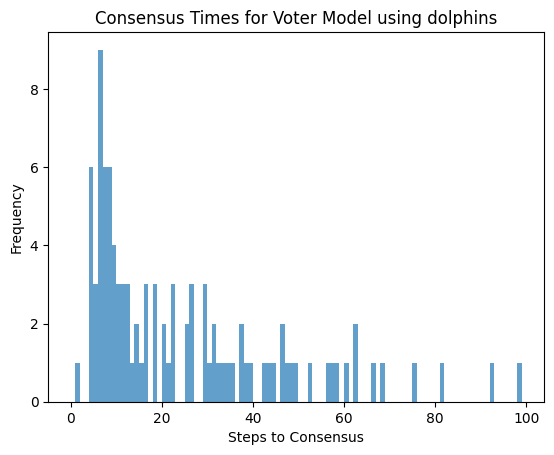

In [ ]:
#Example of applying code from consensus model to whatever is used in problem 3
#this would be how to answer 4a but using whatever graph network you choose instead of 7th graders

#@title setting 1
!echo "deb http://downloads.skewed.de/apt jammy main" >> /etc/apt/sources.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-key 612DEFB798507F25
!apt-get update &> /dev/null
!apt-get install python3-graph-tool python3-matplotlib python3-cairo &> /dev/null

#@title setting 2
# Colab uses a Python install that deviates from the system's! Bad collab! We need some workarounds.
!apt purge python3-cairo &> /dev/null
!apt install libcairo2-dev pkg-config python3-dev &> /dev/null
!pip install --force-reinstall pycairo &> /dev/null
!pip install zstandard &> /dev/null

#@title import libraries

import networkx as nx
import numpy as np
import graph_tool.all as gt
from collections import Counter
import matplotlib.pyplot as plt
import json
import pandas as pd
import csv

print(f"nx: {nx.__version__}")
print(f"graph-tool: {gt.__version__}")

#@title helper functions
def print_summary(name, subname=None):
  for k,v in gt.collection.ns_info[name].items():
    print(k, end="\n----------\n")
    if subname is not None and k == 'analyses':
      v = gt.collection.ns_info[name]['analyses'][subname]
      for ka, va in v.items():
        print(f"{ka}: {va}")
      continue
    if isinstance(v, dict):
      for ka, va in v.items():
        print(f"{ka}: {va}")
    else:
      print(v)
    print("\n")


def prop_to_size_custom(values, min_bound=5, max_bound=15):
    """
    Normalizes a list of floats to be within a specified range [min_bound, max_bound].

    Parameters:
    values (list of float): The list of values to be normalized.
    min_bound (float): The minimum bound of the normalized range (default is 5).
    max_bound (float): The maximum bound of the normalized range (default is 15).

    Returns:
    list of float: The list with values normalized to the specified range.
    """
    min_val = min(values)
    max_val = max(values)
    # Prevent division by zero if all values are the same
    if min_val == max_val:
        return [min_bound] * len(values)

    return [
        min_bound + (value - min_val) * (max_bound - min_bound) / (max_val - min_val)
        for value in values
    ]



###########################################################################

#plt.imshow(A.todense()); # here's what the adj mat looks like
#plt.colorbar()

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def create_network(n, p):
    """Creates a random graph using the Erdős-Rényi model."""
    return nx.erdos_renyi_graph(n, p)

def initialize_states(G, red_fraction):
    """Initialize node states (red or blue) based on the given fraction."""
    states = np.random.choice(['red', 'blue'], size=len(G), p=[red_fraction, 1-red_fraction])
    return states

def voter_step(G, states):
    """Perform one step of the voter model."""
    for node in G.nodes:
        neighbors = list(G.neighbors(node))
        if neighbors:
            chosen_neighbor = np.random.choice(neighbors)
            states[node] = states[chosen_neighbor]

def run_voter_model(G, initial_states, max_steps=100):
    """Run the voter model until consensus or max steps reached."""
    states = initial_states.copy()
    for step in range(max_steps):
        voter_step(G, states)
        if len(set(states)) == 1:  # Check for consensus
            break
    return states, step

def simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps=100):
    """Simulate the voter model multiple times and analyze results."""
    consensus_times = []
    for _ in range(n_runs):
        #G = create_network(n_nodes, edge_prob)
        G = gt.collection.ns["dolphins"]
        A = gt.adjacency(G)
        G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
        #Gnx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph) # be careful, we want a directed graph
        initial_states = initialize_states(G, red_fraction)
        final_states, steps_taken = run_voter_model(G, initial_states, max_steps)
        consensus_times.append(steps_taken)

    return consensus_times

def plot_results(consensus_times):
    """Plot the results of the simulation."""
    plt.hist(consensus_times, bins=range(max(consensus_times) + 1), alpha=0.7)
    plt.xlabel('Steps to Consensus')
    plt.ylabel('Frequency')
    plt.title('Consensus Times for Voter Model using dolphins')
    plt.show()

# Simulation parameters
n_runs = 100
n_nodes = 100
edge_prob = 0.1  # Probability of edge creation
red_fraction = 0.6  # Initial red state fraction
max_steps = 100

# Run simulation
consensus_times = simulate_voter_model(n_runs, n_nodes, edge_prob, red_fraction, max_steps)

# Plot results
plot_results(consensus_times)

consensus_times.mean


In [ ]:
import statistics

mean = statistics.mean(consensus_times)
median = statistics.median(consensus_times)
mode = statistics.mode(consensus_times)
stdev = statistics.stdev(consensus_times)
variance = statistics.variance(consensus_times)

print('mean',mean)
print('median',median)
print('mode',mode)
print('stdev',stdev)
print('variance',variance)


mean 24.49
median 16.0
mode 6
stdev 21.6778502605584
variance 469.9291919191919


# **Additional links to more code for other work donne and versions of problem 4:**

**Additional links to more code for other work done and versions of problem 4:**

https://github.com/trevor-webster/2024Fall-MOCS2/blob/main/notebooks/HW3.3.ipynb

4b might be the only answer that adds anything because of the simulation
https://github.com/trevor-webster/2024Fall-MOCS2/blob/main/notebooks/HW3.4.ipynb

#**Question 2 Additional derivations**

a)Write a heterogeneous mean-field system for an SIS epidemic model on a configuration model network. You should obtain a system of equations for Ii to Ikmax
where kmax is the largest degree in the network. Feel free to nondimensionalize
your system if you wish.

$\frac{d}{dt}N_I$ = -$\mu N_I$ + βK$N_S$ $\frac{N_I}{N}$

$I$ = $\frac{N_I}{N}$

$\frac{d}{dt}I$= -$ \mu$I $ + β $KSI

$\frac{d}{dt}$ $I_i$ = -$\mu I_i$ + β  $\sum_{j} A_{ij}[S_iI_j]$

= $-\mu I_i$ + $ βk_i  \frac{\sum_{j} A_{ij}[S_iI_j]}{k_i}$

$[S_iI_j]$ = $S_i[I_j|S_i]$

= $-\mu I_i$ + $ βk_iS_i  \frac{\sum_{j} A_{ij}[I_j|S_i]}{k_i}$

= $-\mu I_i$ + $ βS_ik_i  \frac{\sum_{j} A_{ij}[I_j|S_i]}{k_i}$

$f_i $ = $k_i  \frac{\sum_{j} A_{ij}[I_j|S_i]}{k_i}$

= $-\mu I_i$ + $ βS_if_i$

$f_i \propto k_i$

$\frac{d}{dt}$ $I_i$ = $-\mu I_i$ + $ βS_if_i$

$\frac{d}{dt}$ $I_i$ = $-\mu I_i$ + $ β(1-I_i)f_i$

to find the equilibrium value of $I_i$, which is the probability that node i is infected at equilibrium state of the disease life set equation = 0 and solve for $I_i$

0 = $-\mu I_i$ + $ β(1-I_i)f_i$

$I_i$ = $\frac{\frac{β}{\mu}f_i}{1+ \frac{β}{\mu}f_i}$